Dataset for Neri Josh O. Atentar (ID: 250014):
                        track_name                artist  duration_min
0         All The Stars (with SZA)        Kendrick Lamar      3.869767
1                          Starboy            The Weeknd      3.840883
2                         Señorita          Shawn Mendes      3.182667
3                       Heat Waves         Glass Animals      3.980083
4                  Let Me Love You              DJ Snake      3.432433
5                         La La La           Naughty Boy      3.679650
6                       Apocalypse  Cigarettes After Sex      4.843600
7                     Good For You          Selena Gomez      3.688000
8                             Baby         Justin Bieber      3.570667
9  There's Nothing Holdin' Me Back          Shawn Mendes      3.324000
Sorted dataset by duration (descending):
                                        track_name                 artist  \
0                                         Lost Boy    

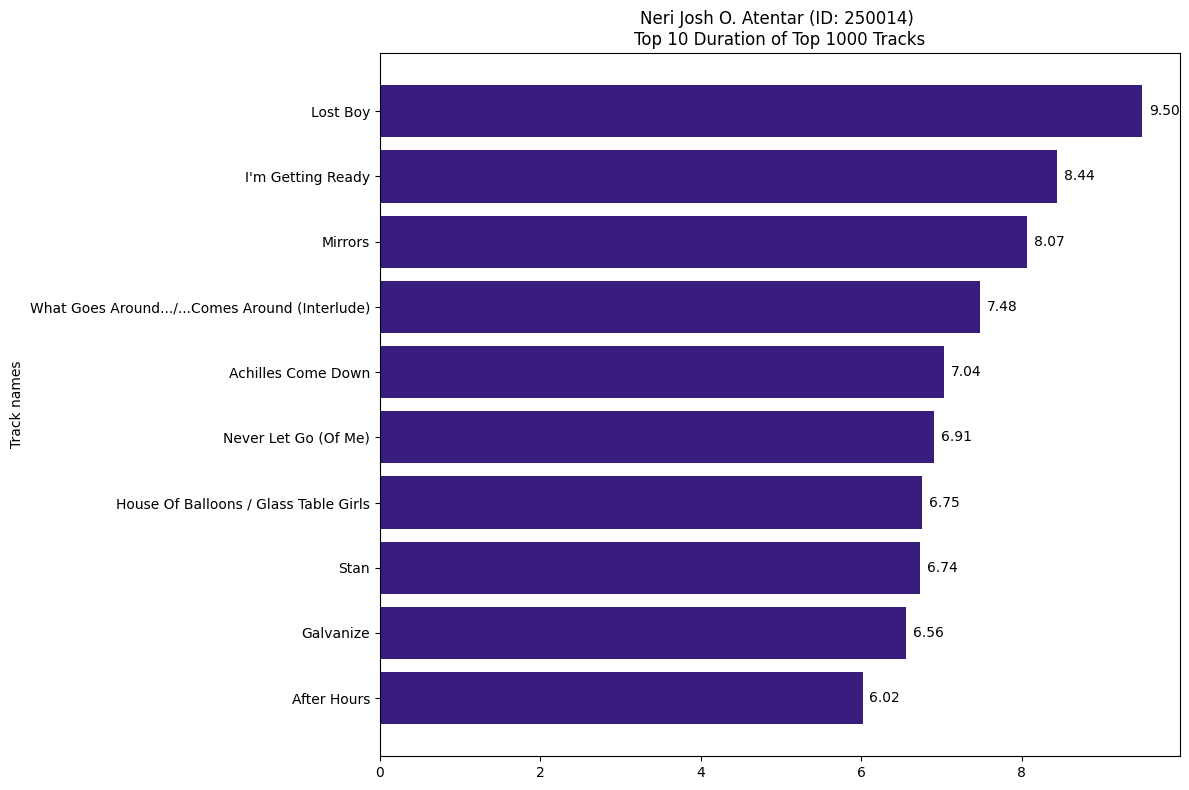

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

student_name = "Neri Josh O. Atentar"
student_id = "250014"
id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 4) % 256:02x}{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}"

data = pd.read_csv('spotify_top_1000_tracks.csv')

cols_to_drop = ['spotify_url', 'id', 'release_date', 'popularity', 'album']
data = data.drop(columns=cols_to_drop, errors='ignore')
sorted_data = data.sort_values(by='duration_min', ascending=False, ignore_index=True)

# Displaying the dataset and sorted dataset
print("=" * 100)
print(f"Dataset for {student_name} (ID: {student_id}):")
print(data.head(10))
print("=" * 100)
print("Sorted dataset by duration (descending):")
print(sorted_data.head(10))
print("=" * 100)

# Bar chart for the top 10 tracks by duration
plt.figure(figsize=(12, 8))
plt.barh(sorted_data['track_name'].head(10), sorted_data['duration_min'].head(10), color=color_bar )
for index in range(len(sorted_data['duration_min'].head(10))):
    plt.annotate(f"{sorted_data['duration_min'].head(10).values[index]:.2f}", xy=(sorted_data['duration_min'].head(10).values[index], index), xytext=(5, 0), textcoords='offset points', ha='left', va='center')
plt.ylabel('Track names')
plt.gca().invert_yaxis()
plt.title(f'{student_name} (ID: {student_id}) \nTop 10 Duration of Top 1000 Tracks')
plt.tight_layout()
plt.savefig("Charts & Plots/Bar chart of duration.png")
plt.show()


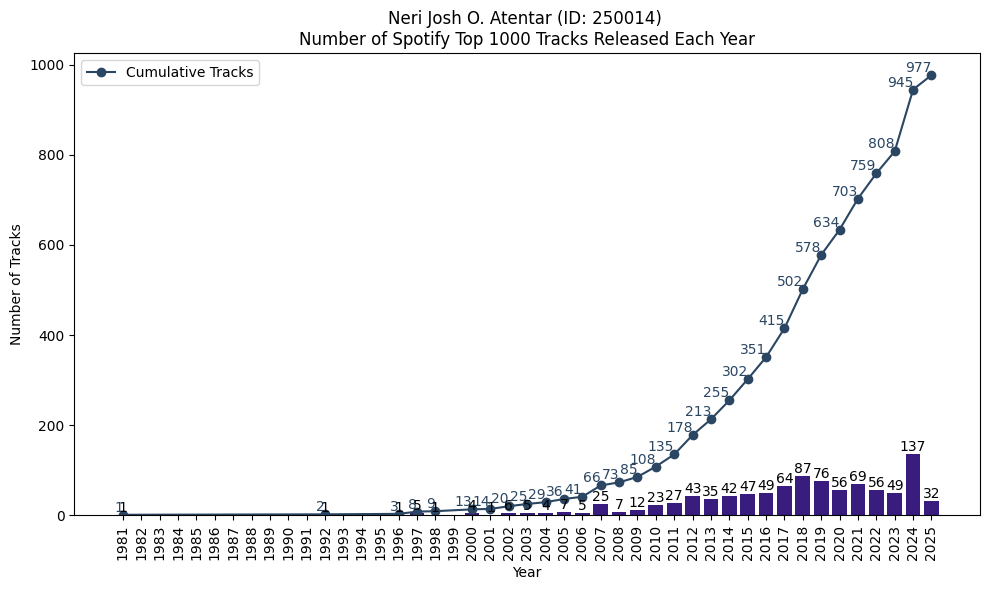

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

student_name = "Neri Josh O. Atentar"
student_id = "250014"
id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 4) % 256:02x}{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}"
color_line = f"#{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}{(id_num * 7) % 256:02x}"

data = pd.read_csv('spotify_top_1000_tracks.csv')

df = data[['release_date']]
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df[['year']]

counts = df['year'].value_counts().sort_index()
cummulative_counts = counts.cumsum()

# Bar chart for the number of tracks released each year
# Line chart for the cumulative number of tracks released over the years
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color=color_bar)
plt.plot(cummulative_counts.index, cummulative_counts.values, color=color_line, marker='o', label='Cumulative Tracks')
plt.xlabel('Year')
plt.ylabel('Number of Tracks')
plt.legend()
plt.xticks(np.arange(counts.index.min(), counts.index.max() + 1, 1), rotation=90)
for index in range(len(cummulative_counts.index)):
    plt.text(cummulative_counts.index[index], cummulative_counts.values[index], cummulative_counts.values[index], ha='right', va='bottom', color=color_line)
for index in range(len(counts.index)):
    plt.text(counts.index[index], counts.values[index], counts.values[index], ha='center', va='bottom')
plt.title(f'{student_name} (ID: {student_id}) \nNumber of Spotify Top 1000 Tracks Released Each Year')
plt.tight_layout()
plt.savefig("Charts & Plots/Bar and Line chart of track releases.png")
plt.show()


GIF saved at: c:\Users\msi\OneDrive\Documents\ATENTAR\Lab8_Data_Visualization_Atentar\Lab8_Additional_Exercise\Charts & Plots\Hexbin.gif


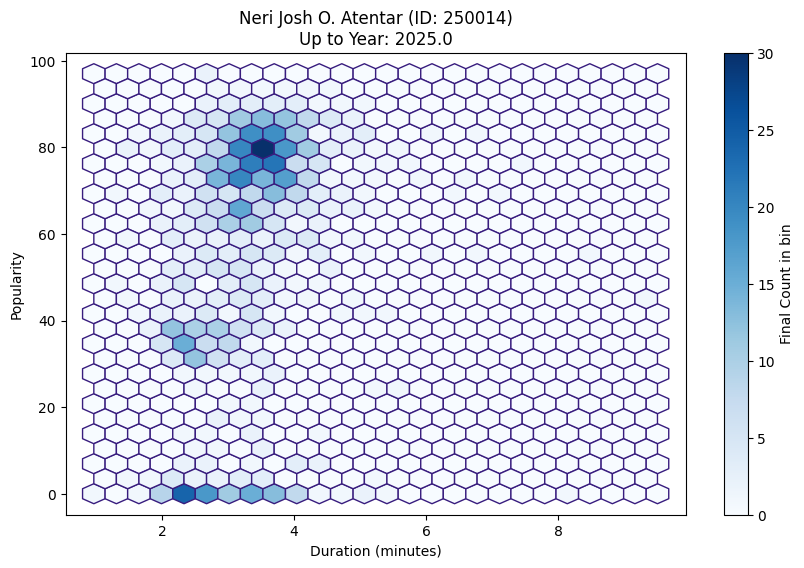

In [16]:
import os
from matplotlib import cm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# Student-specific Parameters
student_name = "Neri Josh O. Atentar"
student_id = "250014"
id_num = int(student_id[-3:])
cmap_color = f"#{(id_num * 4) % 256:02x}{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}"

# Load csv
df = pd.read_csv(
    'spotify_top_1000_tracks.csv',
    usecols=['duration_min', 'popularity', 'release_date'],
)

# Preprocess once
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Clean data
df = df.dropna(subset=['duration_min', 'popularity', 'year'])

# Sort by year
df = df.sort_values('year')

# Unique years for animation frames
years = df['year'].unique()

# Parameters for hexbin
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Popularity')
ax.set_title(f'{student_name} (ID: {student_id})\nHexbin Evolution')

# Create hexbin
hex = ax.hexbin([], [], gridsize=25, cmap='Blues')
norm = plt.Normalize(vmin=0, vmax=30) 
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='Blues'), ax=ax, label='Final Count in bin',)
    
# Animation function
def animate(i):
    ax.clear()
    
    year = years[i]
    subset = df[df['year'] <= year]

    hb = ax.hexbin(
        subset['duration_min'],
        subset['popularity'],
        gridsize=25,
        cmap='Blues',
        edgecolors='grey',
        color = cmap_color
    )

    ax.set_title(f'{student_name} (ID: {student_id})\nUp to Year: {year}')
    ax.set_xlabel('Duration (minutes)')
    ax.set_ylabel('Popularity')


    return hb,

# Animate 
ani = FuncAnimation(
    fig,
    animate,
    frames=len(years),
    interval=150,
    repeat=False
)

# Save GIF 
gif_path = os.path.abspath("Charts & Plots/Hexbin.gif")
ani.save(gif_path, writer=PillowWriter(fps=5))

print("GIF saved at:", gif_path)

plt.show()
webbrowser.open(f"file://{gif_path}")
plt.close(fig)